In [5]:
import pandas as pd

df = pd.read_csv("Fraud (1).csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.shape


(6362620, 11)

In [7]:
df['isFraud'].value_counts()


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)
df.head()


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [9]:
df['type'].value_counts()


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [10]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)
df.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,True,False


In [11]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

df['largeAmount'] = (df['amount'] > 200000).astype(int)

df.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,balanceDiffOrig,balanceDiffDest,largeAmount
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,True,False,9839.64,0.0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,True,False,1864.28,0.0,0
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,True,181.00,0.0,0
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,True,False,False,False,181.00,-21182.0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,True,False,11668.14,0.0,0


In [12]:
df.columns


Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'balanceDiffOrig',
       'balanceDiffDest', 'largeAmount'],
      dtype='object')

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

y_train_res.value_counts()


isFraud
0    5083526
1    5083526
Name: count, dtype: int64

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_res, y_train_res)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))



              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.93      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.94      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

ROC AUC: 0.9877906989115204


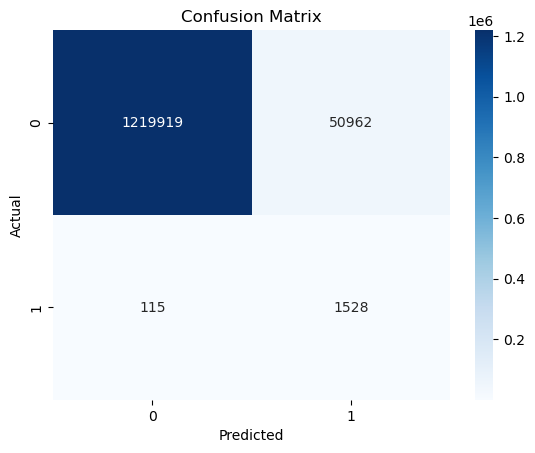

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [18]:
threshold = 0.3   # pehle 0.3 try karo
y_pred_03 = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_03))


              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1270881
           1       0.02      0.97      0.03      1643

    accuracy                           0.92   1272524
   macro avg       0.51      0.95      0.50   1272524
weighted avg       1.00      0.92      0.96   1272524



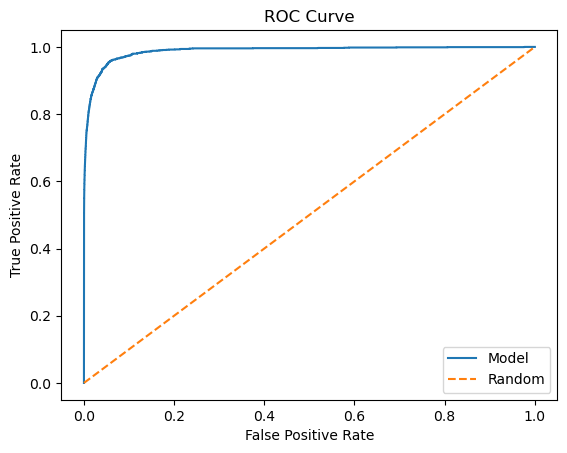

In [19]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Model")
plt.plot([0,1], [0,1], '--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [20]:
for t in [0.2, 0.3, 0.5]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))



Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      0.89      0.94   1270881
           1       0.01      0.98      0.02      1643

    accuracy                           0.89   1272524
   macro avg       0.51      0.93      0.48   1272524
weighted avg       1.00      0.89      0.94   1272524


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.92      0.96   1270881
           1       0.02      0.97      0.03      1643

    accuracy                           0.92   1272524
   macro avg       0.51      0.95      0.50   1272524
weighted avg       1.00      0.92      0.96   1272524


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.93      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.94      0.52   1272524
weighted avg       1.00   

In [21]:
importance = pd.Series(
    lr_model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

importance.head(10)


type_PAYMENT      -3.566800
type_TRANSFER      1.019978
largeAmount       -0.339094
type_CASH_OUT      0.219138
type_DEBIT        -0.055739
isFlaggedFraud     0.024478
step               0.005307
balanceDiffOrig    0.000020
newbalanceOrig    -0.000011
oldbalanceOrg      0.000010
dtype: float64

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    n_estimators=100,
    max_depth=5
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_prob_xgb))



XGBoost ROC AUC: 0.9991769797939035


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.21      1.00      0.35      1643

    accuracy                           1.00   1272524
   macro avg       0.61      1.00      0.67   1272524
weighted avg       1.00      1.00      1.00   1272524



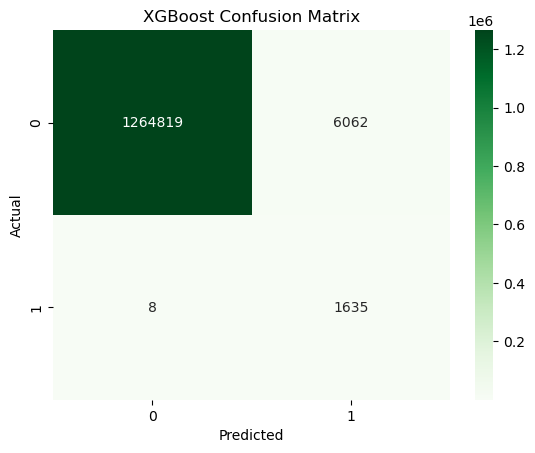

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [28]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t))



Threshold = 0.2
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.14      1.00      0.25      1643

    accuracy                           0.99   1272524
   macro avg       0.57      1.00      0.62   1272524
weighted avg       1.00      0.99      1.00   1272524


Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.16      1.00      0.28      1643

    accuracy                           0.99   1272524
   macro avg       0.58      1.00      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524


Threshold = 0.4
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.19      1.00      0.32      1643

    accuracy                           0.99   1272524
   macro avg       0.59      1.00      0.66   1272524
weighted avg       1.00

In [29]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(10)


type_PAYMENT       0.315704
oldbalanceDest     0.228879
oldbalanceOrg      0.184252
amount             0.175274
newbalanceOrig     0.090122
newbalanceDest     0.003347
step               0.001320
balanceDiffDest    0.000501
isFlaggedFraud     0.000405
balanceDiffOrig    0.000151
dtype: float32

In [30]:
import joblib
joblib.dump(xgb, "fraud_xgb_model.pkl")


['fraud_xgb_model.pkl']

In [32]:
!pip freeze > requirements.txt
